In [72]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI


In [73]:
class EvaluatorSchema(BaseModel):
  evaluation_result: str = Literal["needs_improvement", "approved", "inappropriate_topic"]
  reason_for_improvement: str = Field(description="Reason for improvement in case the evaluation result is needs_improvement")

In [74]:
llm = ChatGoogleGenerativeAI(
  model="gemini-3.1-flash-lite"
)
generator_llm = ChatGroq(
  model_name="llama-3.3-70b-versatile"
)

In [75]:
evaluator_structured_model = llm.with_structured_output(EvaluatorSchema)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\json_schema.py:2466: PydanticJsonSchemaWarning: Default value typing.Literal['needs_improvement', 'approved', 'inappropriate_topic'] is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [76]:
class TweetGeneratorState(TypedDict):
  topic: str
  post: str
  evaluation_result: str
  evaluation_reason: str
  optimized_post: str
  optimized_post_count: int
  route: str

In [77]:
def generate_post(state: TweetGeneratorState):
  """Generate the post on a specific topic."""

  topic = state['topic']

  prompt = f"""Generate a humanized post for my X (Twitter) platform on this topic: {topic}.
  Keep the tone engaging, witty, and technical when appropriate.
  Do not generate content on inappropriate, unsafe, or disallowed topics.
  Refuse and return a brief safety-focused message if the topic involves sexual content, explicit adult content, hate, harassment, violence, self-harm, illegal activity, or other harmful material.
  If the topic is borderline or unsafe, do not try to adapt it into a post."""

  response = generator_llm.invoke(prompt)
  post = response.content

  return {
    "post": post
  }


def evaluate_post(state: TweetGeneratorState):
  """Evaluate the llm generated post and the give the evaluation result."""

  topic = state['topic']
  post = state['post']
  optimized_post = state.get("optimized_post", "")

  evaluator_prompt = f"""You are an expert post evaluator. 
    evaluate the given post on the given topic and then give the evaluation result. Only give the reason for improvement if the evaluation result is needs_improvement.

    Topic: {topic}
    Post: {optimized_post if not optimized_post == "" else post}

    ### Evaluation Criteria
    1. Accuracy: The response must contain no factual errors or hallucinations.
    2. Relevance: The response must directly answer the prompt without fluff.
    3. Logic: Arguments and steps must follow a clear, coherent progression.

    Return only one of these two strings in the evaluation_result:
      "approved" or "needs_improvement" or "inappropriate_topic". Nothing else should be set in the evaluation result
  """

  response = evaluator_structured_model.invoke(evaluator_prompt)
  evr = response.evaluation_result
  ri = response.reason_for_improvement
  route = "end"
  
  if evr == "needs_improvement":
    route = "optimize_post"

  return {
    "evaluation_result": evr,
    "evaluation_reason": ri,
    "route": route
  }


def optimize_post(state: TweetGeneratorState):
  """Optimize the post on the basis of evaluation result."""

  evaluation_result = state['evaluation_result']
  evaluation_reason = state.get('evaluation_reason', '')
  optimized_post_count = state.get("optimized_post_count", 0)

  prompt = f"""
    Optimize this post without repeating the same mistakes. The evaluation result is {evaluation_result}. And the evaluation reason is {evaluation_reason if not evaluation_reason == "" else ""}.
    Optimize this post based on these given above metrics. 
  """

  response = generator_llm.invoke(prompt)
  optimized_post = response.content
  count = optimized_post_count + 1
  route = "evaluate_post"

  if count >= 3:
    route = "end"

  return {
    "optimized_post": optimized_post,
    "route": route,
    "optimized_post_count": count
  }


In [78]:
def select_route(state: TweetGeneratorState):
  return state["route"]

In [79]:
graph = StateGraph(TweetGeneratorState)

graph.add_node("generate_post", generate_post)
graph.add_node("evaluate_post", evaluate_post)
graph.add_node("optimize_post", optimize_post)

graph.add_edge(START, "generate_post")
graph.add_edge("generate_post", "evaluate_post")
graph.add_conditional_edges(
  "evaluate_post",
  select_route,
  {
    "optimize_post": "optimize_post",
    "end": END
  }
)
graph.add_conditional_edges(
  "optimize_post", 
  select_route,
  {
    "evaluate_post": "evaluate_post",
    "end": END
  }
)

workflow = graph.compile()

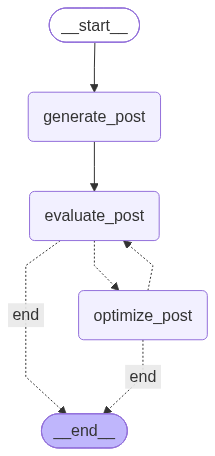

In [80]:
workflow

In [81]:
topic = "multi agent orchestration"

In [83]:
workflow.invoke({
  "topic": topic
})

{'topic': 'multi agent orchestration',
 'post': '"Get ready for a symphony of systems! Multi-agent orchestration is like conducting a tech orchestra, where each \'musician\' (agent) plays its part in perfect harmony. But instead of notes, they\'re exchanging data and coordinating actions to achieve a common goal. Imagine a world where autonomous vehicles, smart homes, and IoT devices work together seamlessly. The future of tech is all about harmony and efficiency! #MultiAgentOrchestration #TechSymphony #Innovation"',
 'evaluation_result': 'approved',
 'evaluation_reason': '',
 'optimized_post': "To optimize the post on multi-agent orchestration, I will focus on providing technical substance while minimizing the reliance on metaphors. Here's a rewritten version:\n\n**Introduction to Multi-Agent Orchestration**\n\nMulti-agent orchestration refers to the coordination of multiple autonomous agents to achieve a common goal. This concept has gained significant attention in recent years, part